# Diabetes Data Cleaning & Exploratory Visualization

A compact healthcare data case study combining **data-quality checks, missing-value treatment, feature engineering, and exploratory visualization**.

The workflow identifies biologically implausible zero values in several clinical measurements, converts them to missing data, applies mean imputation, and uses simple visual summaries to communicate data quality and outcome patterns.

**Tools:** Python · Pandas · NumPy · Matplotlib

## 1. Load and inspect the data

The analysis expects a local file at `data/health_data.csv`. The dataset contains 768 participant records and nine clinical or outcome variables.

In [ ]:
import numpy as np
import pandas as pd

df = pd.read_csv("data/health_data.csv")
df.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


## 2. Identify zero-coded missing values

Several clinical measurements contain zeros that are not plausible observed values. Before treating them as missing, it is useful to visualize where the data-quality problem is concentrated.

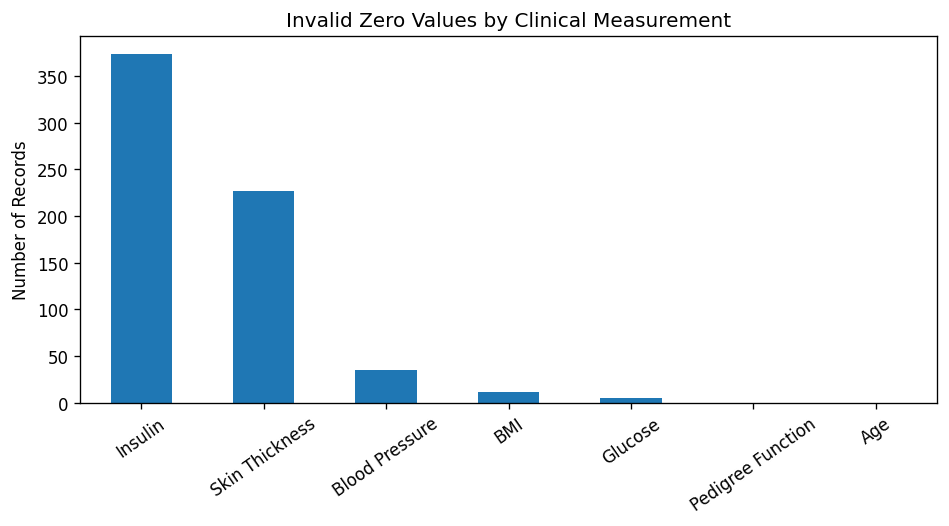

In [ ]:
clinical_columns = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age",
]

invalid_zero_counts = (df[clinical_columns] == 0).sum().sort_values(ascending=False)

ax = invalid_zero_counts.plot(kind="bar", figsize=(8, 4.5))
ax.set_title("Invalid Zero Values by Clinical Measurement")
ax.set_ylabel("Number of Records")
ax.set_xlabel("")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

The largest data-quality issue appears in **Insulin** and **Skin Thickness**, while Glucose, Blood Pressure, and BMI contain fewer zero-coded missing values. Age and Diabetes Pedigree Function do not show this issue.

## 3. Convert invalid zeros to missing values and impute

The selected invalid zeros are converted to `NaN`. Mean imputation is then used to create a complete analysis-ready table. For predictive modeling, a more robust imputation strategy could be evaluated.

In [ ]:
df[clinical_columns] = df[clinical_columns].replace(0, np.nan)

missing_before_imputation = df.isna().sum()
missing_before_imputation


,0
Pregnancies,0
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [ ]:
df = df.fillna(df.mean(numeric_only=True))

missing_after_imputation = df.isna().sum()
missing_after_imputation


,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


## 4. Explore the outcome distribution

Before comparing groups, the overall target balance provides context for interpreting percentages and model performance later on.

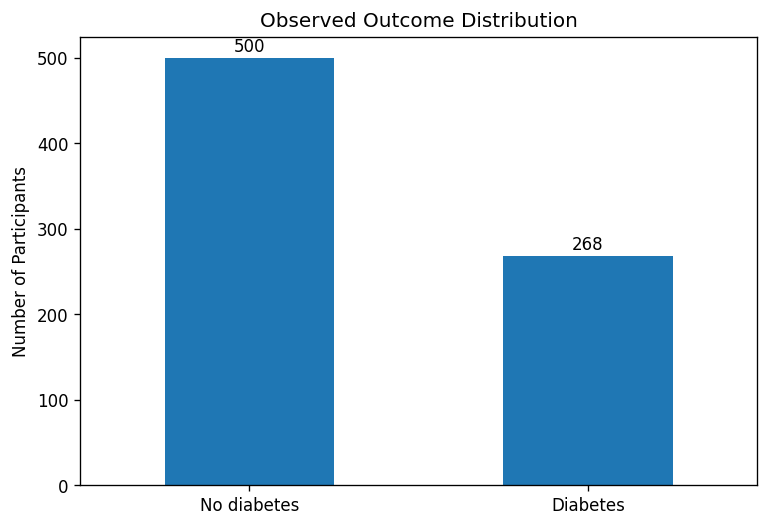

In [ ]:
outcome_counts = (
    df["Outcome"]
    .map({0: "No diabetes", 1: "Diabetes"})
    .value_counts()
    .reindex(["No diabetes", "Diabetes"])
)

ax = outcome_counts.plot(kind="bar", figsize=(6.5, 4.5))
ax.set_title("Observed Outcome Distribution")
ax.set_ylabel("Number of Participants")
ax.set_xlabel("")
plt.xticks(rotation=0)

for i, value in enumerate(outcome_counts.values):
    ax.text(i, value + 8, str(value), ha="center")

plt.tight_layout()
plt.show()

The dataset contains **500 negative outcomes** and **268 positive outcomes**, so the target is moderately imbalanced rather than evenly split.

## 5. Create a pregnancy-history feature

A binary feature separates participants with at least one recorded pregnancy from those with zero recorded pregnancies.

In [ ]:
df["has_pregnancy_history"] = (df["Pregnancies"] > 0).astype(int)

df[["Pregnancies", "has_pregnancy_history", "Outcome"]].head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,Pregnant_bool
0,6,148.0,72.0,35.00000,155.548223,33.6,0.627,50,1,1
1,1,85.0,66.0,29.00000,155.548223,26.6,0.351,31,0,1
2,8,183.0,64.0,29.15342,155.548223,23.3,0.672,32,1,1
3,1,89.0,66.0,23.00000,94.000000,28.1,0.167,21,0,1
4,0,137.0,40.0,35.00000,168.000000,43.1,2.288,33,1,0


## 6. Compare outcome rates by pregnancy history

A grouped rate comparison checks whether the positive-outcome proportion differs noticeably between participants with and without recorded pregnancy history.

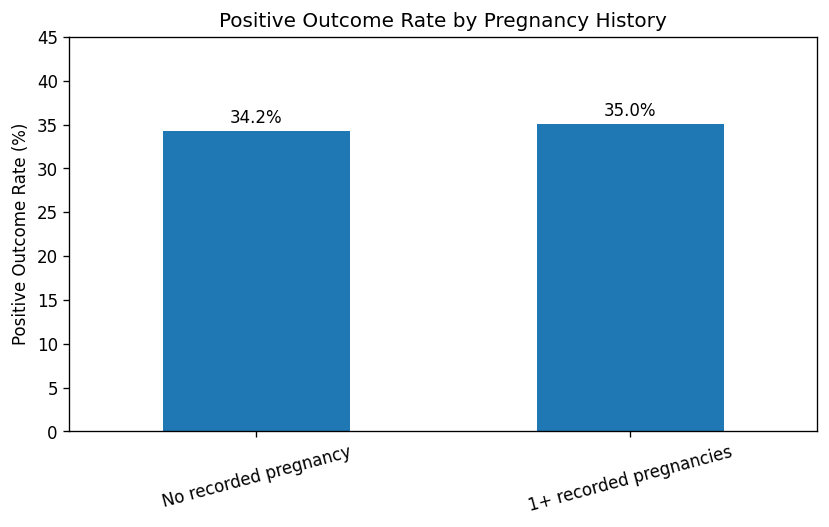

In [ ]:
outcome_by_history = (
    df.groupby("has_pregnancy_history")["Outcome"]
      .mean()
      .rename(index={0: "No recorded pregnancy", 1: "1+ recorded pregnancies"})
      .mul(100)
)

ax = outcome_by_history.plot(kind="bar", figsize=(7, 4.5))
ax.set_title("Positive Outcome Rate by Pregnancy History")
ax.set_ylabel("Positive Outcome Rate (%)")
ax.set_xlabel("")
ax.set_ylim(0, 45)
plt.xticks(rotation=15)

for i, value in enumerate(outcome_by_history.values):
    ax.text(i, value + 1, f"{value:.1f}%", ha="center")

plt.tight_layout()
plt.show()

The observed positive-outcome rates are very similar between the two groups—approximately **34.2%** for participants with no recorded pregnancies and **35.0%** for those with one or more. This is a descriptive comparison and should not be interpreted causally.

## 7. Key takeaways

- Data-quality problems can be hidden behind numeric values when sentinel values such as zero are used.
- **Insulin** and **Skin Thickness** contain the largest number of implausible zero values in this dataset.
- The outcome variable is moderately imbalanced, with 268 positive outcomes versus 500 negative outcomes.
- Mean imputation creates a complete table for analysis, but it can reduce variance and should be reconsidered for predictive modeling.
- Pregnancy history alone does not show a substantial difference in the observed positive-outcome rate in this dataset.